In [20]:
import pandas as pd

# 1. Lê os arquivos direto do seu computador com a codificação correta
df_limpo = pd.read_csv('tabela_9543_padronizada - LimpoFinal.csv', encoding='ISO-8859-1')

# 2. Mostra as colunas na tela imediatamente
print("--- COLUNAS DE MUNICÍPIOS ---")
print(df_municipios.columns.tolist())

print("\n--- COLUNAS DA TABELA LIMPA ---")
print(df_limpo.columns.tolist())

--- COLUNAS DE MUNICÍPIOS ---
['NÃ\xadvel Territorial (CÃ³digo);NÃ\xadvel Territorial;Unidade de Medida (CÃ³digo);Unidade de Medida;Valor;MunicÃ\xadpio (CÃ³digo);MunicÃ\xadpio;VariÃ¡vel (CÃ³digo);VariÃ¡vel;Ano (CÃ³digo);Ano;Sexo (CÃ³digo);Sexo;Cor ou raÃ§a (CÃ³digo);Cor ou raÃ§a;Idade (CÃ³digo);Idade']

--- COLUNAS DA TABELA LIMPA ---
['Identificação1;Identificação;cod_municipio;municipio;indicador;sexo;cor_raca;grupo_idade;taxa_alfabetizacao;uf;municipio_nome;municipio_padrao;chave_municipio_uf']


In [13]:
# 1. Quantas linhas e colunas existem no total?
print(f"A tabela tem o total de {df_limpo.shape[0]} linhas e {df_limpo.shape[1]} colunas.\n")

# 2. Quais são todos os Estados (UF) que estão nessa tabela?
print("Estados (UF) presentes na tabela:")
print(df_limpo['uf'].unique())

# 3. Quais são os sexos registrados na tabela toda?
print("\nCategorias de Sexo:")
print(df_limpo['sexo'].unique())

# 4. Quais são as cores/raças registradas na tabela toda?
print("\nCategorias de Cor ou Raça:")
print(df_limpo['cor_raca'].unique())

# 5. Quais são as faixas de idade registradas na tabela toda?
print("\nGrupos de Idade:")
print(df_limpo['grupo_idade'].unique())

A tabela tem o total de 6879 linhas e 13 colunas.

Estados (UF) presentes na tabela:
<StringArray>
['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO', 'MA', 'PI', 'CE', 'RN', 'PB', 'PE',
 'AL', 'SE', 'BA', 'MG', 'ES', 'RJ', 'SP', 'PR', 'SC', 'RS', 'MS', 'MT', 'GO',
 'DF']
Length: 27, dtype: str

Categorias de Sexo:
<StringArray>
['Homens', 'Mulheres']
Length: 2, dtype: str

Categorias de Cor ou Raça:
<StringArray>
['Branca', 'Preta']
Length: 2, dtype: str

Grupos de Idade:
<StringArray>
['15 anos']
Length: 1, dtype: str


In [14]:
# Agrupa por estado e calcula a média da taxa de alfabetização, ordenando do maior para o menor
ranking_estados = df_limpo.groupby('uf')['taxa_alfabetizacao'].mean().sort_values(ascending=False)
print("--- RANKING DA TAXA DE ALFABETIZAÇÃO POR ESTADO ---")
print(ranking_estados)

--- RANKING DA TAXA DE ALFABETIZAÇÃO POR ESTADO ---
uf
DF    99.237500
RJ    97.749140
SC    97.282134
SP    96.690947
PR    96.114957
RS    95.883163
ES    95.874018
MS    95.429753
RO    95.420000
RR    95.388333
PA    94.542395
PE    94.467656
AC    94.367619
GO    94.083725
BA    93.944043
MT    93.758283
MG    93.578824
CE    93.256536
AL    92.752438
AP    92.718387
MA    92.456362
RN    91.958797
SE    91.853630
AM    91.676275
PB    89.848556
PI    88.102440
TO    88.023704
Name: taxa_alfabetizacao, dtype: float64


In [16]:
print("\n--- MÉDIA POR COR OU RAÇA ---")
print(df_limpo.groupby('cor_raca')['taxa_alfabetizacao'].mean())


--- MÉDIA POR COR OU RAÇA ---
cor_raca
Branca    95.707964
Preta     90.393776
Name: taxa_alfabetizacao, dtype: float64


In [15]:

print("--- MÉDIA POR SEXO ---")
print(df_limpo.groupby('sexo')['taxa_alfabetizacao'].mean())

--- MÉDIA POR SEXO ---
sexo
Homens      93.200669
Mulheres    95.302787
Name: taxa_alfabetizacao, dtype: float64


In [17]:
print("--- CRUZAMENTO: SEXO E COR/RAÇA ---")
display(df_limpo.pivot_table(values='taxa_alfabetizacao', index='cor_raca', columns='sexo', aggfunc='mean'))

--- CRUZAMENTO: SEXO E COR/RAÇA ---


sexo,Homens,Mulheres
cor_raca,,
Branca,95.166974,96.453158
Preta,89.488657,92.184178


In [22]:
print(df_limpo.columns.tolist())

['Identificação1;Identificação;cod_municipio;municipio;indicador;sexo;cor_raca;grupo_idade;taxa_alfabetizacao;uf;municipio_nome;municipio_padrao;chave_municipio_uf']


In [23]:
values='NOME_EXATO_QUE_APARECEU_NA_LISTA'

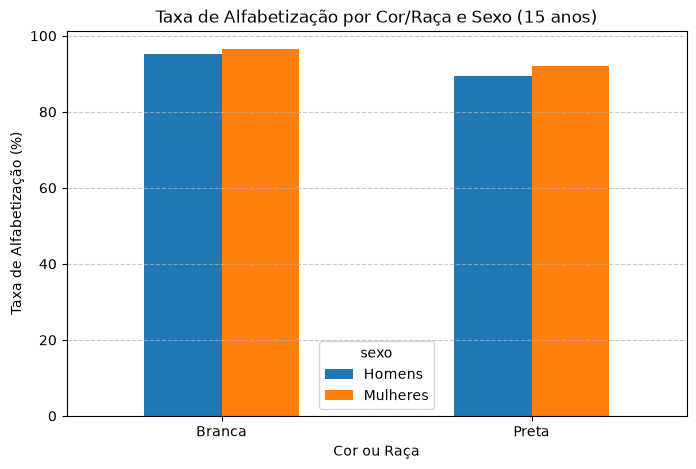

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Recarrega a tabela separando as colunas por ';' corretamente
df_limpo = pd.read_csv('tabela_9543_padronizada - LimpoFinal.csv', sep=';', encoding='ISO-8859-1')

# 2. Cria a tabela cruzada (Pivot Table) agora com as colunas separadas
tabela_cruzada = df_limpo.pivot_table(
    values='taxa_alfabetizacao', 
    index='cor_raca', 
    columns='sexo', 
    aggfunc='mean'
)

# 3. Desenha o gráfico de barras
tabela_cruzada.plot(kind='bar', figsize=(8, 5), color=['#1f77b4', '#ff7f0e'])

# 4. Configurações visuais do gráfico
plt.title('Taxa de Alfabetização por Cor/Raça e Sexo (15 anos)')
plt.ylabel('Taxa de Alfabetização (%)')
plt.xlabel('Cor ou Raça')
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Exibe o gráfico na tela
plt.show()

--- VALORES EXATOS (MULHERES) ---
cor_raca
Branca    96.453158
Preta     92.184178
Name: taxa_alfabetizacao, dtype: float64

--- GERANDO O GRÁFICO ---


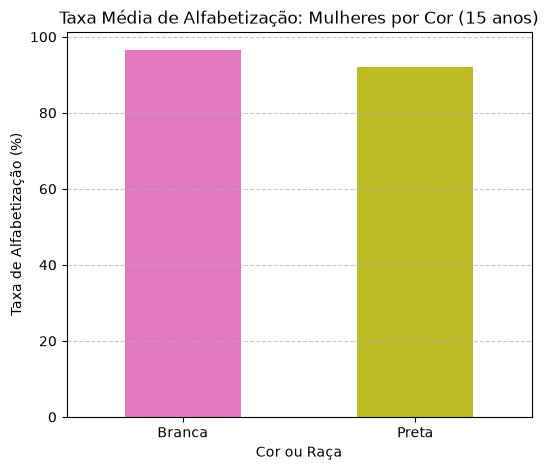

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Garante que a tabela está carregada corretamente com o separador ';'
df_limpo = pd.read_csv('tabela_9543_padronizada - LimpoFinal.csv', sep=';', encoding='ISO-8859-1')

# 2. Filtra a tabela para manter APENAS as mulheres
df_mulheres = df_limpo[df_limpo['sexo'] == 'Mulheres']

# 3. Calcula a média da taxa de alfabetização por cor/raça das mulheres
media_mulheres_cor = df_mulheres.groupby('cor_raca')['taxa_alfabetizacao'].mean()

# 4. Desenha o gráfico de barras comparativo
plt.figure(figsize=(6, 5))
media_mulheres_cor.plot(kind='bar', color=['#e377c2', '#bcbd22'])

# 5. Configurações visuais e títulos
plt.title('Taxa Média de Alfabetização: Mulheres por Cor (15 anos)')
plt.ylabel('Taxa de Alfabetização (%)')
plt.xlabel('Cor ou Raça')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibe os valores exatos em texto acima do gráfico para complementar
print("--- VALORES EXATOS (MULHERES) ---")
print(media_mulheres_cor)
print("\n--- GERANDO O GRÁFICO ---")

plt.show()

--- VALORES EXATOS (HOMENS) ---
cor_raca
Branca    95.166974
Preta     89.488657
Name: taxa_alfabetizacao, dtype: float64

--- GERANDO O GRÁFICO ---


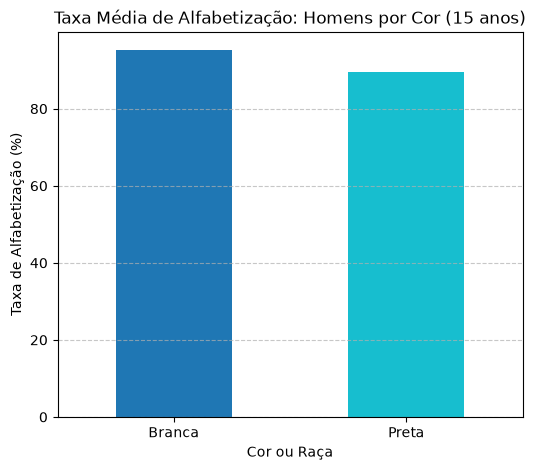

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Garante que a tabela está carregada corretamente com o separador ';'
df_limpo = pd.read_csv('tabela_9543_padronizada - LimpoFinal.csv', sep=';', encoding='ISO-8859-1')

# 2. Filtra a tabela para manter APENAS os homens
df_homens = df_limpo[df_limpo['sexo'] == 'Homens']

# 3. Calcula a média da taxa de alfabetização por cor/raça dos homens
media_homens_cor = df_homens.groupby('cor_raca')['taxa_alfabetizacao'].mean()

# 4. Desenha o gráfico de barras comparativo
plt.figure(figsize=(6, 5))
media_homens_cor.plot(kind='bar', color=['#1f77b4', '#17becf'])

# 5. Configurações visuais e títulos
plt.title('Taxa Média de Alfabetização: Homens por Cor (15 anos)')
plt.ylabel('Taxa de Alfabetização (%)')
plt.xlabel('Cor ou Raça')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibe os valores exatos em texto acima do gráfico para complementar
print("--- VALORES EXATOS (HOMENS) ---")
print(media_homens_cor)
print("\n--- GERANDO O GRÁFICO ---")

plt.show()

--- TAXA MÉDIA DE ALFABETIZAÇÃO POR REGIÃO (15 ANOS) ---
regiao
Sul             96.305253
Sudeste         95.496405
Centro-Oeste    94.334820
Norte           93.255787
Nordeste        92.530053
Name: taxa_alfabetizacao, dtype: float64

--- GERANDO O GRÁFICO POR REGIÃO ---


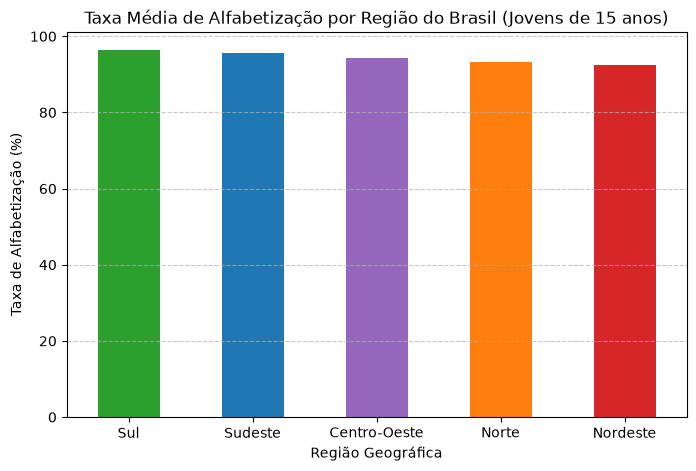

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Garante que a tabela está carregada corretamente com o separador ';'
df_limpo = pd.read_csv('tabela_9543_padronizada - LimpoFinal.csv', sep=';', encoding='ISO-8859-1')

# 2. Criando o dicionário para mapear quais Estados pertencem a quais Regiões
mapeamento_regioes = {
    'RO': 'Norte', 'AC': 'Norte', 'AM': 'Norte', 'RR': 'Norte', 'PA': 'Norte', 'AP': 'Norte', 'TO': 'Norte',
    'MA': 'Nordeste', 'PI': 'Nordeste', 'CE': 'Nordeste', 'RN': 'Nordeste', 'PB': 'Nordeste', 
    'PE': 'Nordeste', 'AL': 'Nordeste', 'SE': 'Nordeste', 'BA': 'Nordeste',
    'MG': 'Sudeste', 'ES': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'SC': 'Sul', 'RS': 'Sul',
    'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'DF': 'Centro-Oeste'
}

# 3. Cria a nova coluna 'regiao' na tabela associando os estados
df_limpo['regiao'] = df_limpo['uf'].map(mapeamento_regioes)

# 4. Calcula a taxa média de alfabetização por Região
media_regiao = df_limpo.groupby('regiao')['taxa_alfabetizacao'].mean().sort_values(ascending=False)

# 5. Exibe a tabela de resultados na tela
print("--- TAXA MÉDIA DE ALFABETIZAÇÃO POR REGIÃO (15 ANOS) ---")
print(media_regiao)

# 6. Gera um gráfico de barras bem visual para as regiões
print("\n--- GERANDO O GRÁFICO POR REGIÃO ---")
plt.figure(figsize=(8, 5))
media_regiao.plot(kind='bar', color=['#2ca02c', '#1f77b4', '#9467bd', '#ff7f0e', '#d62728'])
plt.title('Taxa Média de Alfabetização por Região do Brasil (Jovens de 15 anos)')
plt.ylabel('Taxa de Alfabetização (%)')
plt.xlabel('Região Geográfica')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()